# NDVI Time Series Analysis - Kinshasa (2022)

## 1. Introduction

Monitoring vegetation dynamics is essential for understanding environmental changes and land use patterns. One of the most widely used indicators for vegetation analysis is the Normalized Difference Vegetation Index (NDVI), which provides information about vegetation health and density using satellite imagery.

In this study, NDVI time series are analyzed for three different land cover classes (forest, cropland, and urban areas) in Kinshasa, Democratic Republic of Congo, for the year 2022. The analysis is based on Sentinel-2 satellite data processed using openEO. Monthly mean NDVI values are computed for each class in order to capture seasonal variations in vegetation activity.

The objective of this work is to compare vegetation dynamics across different land cover types and to assess how seasonal patterns influence NDVI values in a tropical environment.

In [1]:
!pip install openeo

Defaulting to user installation because normal site-packages is not writeable


In [2]:
#Install required libraries
import sys
!{sys.executable} -m pip install openeo rioxarray geopandas leafmap xarray

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import sys
!{sys.executable} -m pip install rioxarray

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# import platform libraries
import openeo

# import utility libraries
from datetime import date
import numpy as np
import xarray as xr
import rioxarray
import json
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import leafmap.foliumap as leafmap

In [5]:
conn = openeo.connect('https://openeo.dataspace.copernicus.eu/')

In [6]:
conn.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [7]:
conn.describe_account()

{'info': {'oidc_userinfo': {'email': 'kandjaleyolima@gmail.com',
   'email_verified': True,
   'family_name': 'Espérance',
   'given_name': 'Kandjale',
   'name': 'Kandjale Espérance',
   'preferred_username': 'kandjaleyolima@gmail.com',
   'sub': 'c8d0301e-a561-41c8-b4a9-ee6f2816e672'}},
 'name': 'Kandjale Espérance',
 'user_id': 'c8d0301e-a561-41c8-b4a9-ee6f2816e672'}

In [8]:
import leafmap

In [9]:
import leafmap.leafmap as leafmap

## 2. Study Area

In [10]:
# Define study area

from shapely.geometry import Polygon
import geopandas as gpd

# Bounding box de Kinshasa
kinshasa_polygon = Polygon([
    (15.15, -4.50),
    (15.45, -4.50),
    (15.45, -4.20),
    (15.15, -4.20),
    (15.15, -4.50)
])

study_area = gpd.GeoDataFrame(index=[0], geometry=[kinshasa_polygon], crs="EPSG:4326")

study_area

,geometry
0,"POLYGON ((15.15 -4.5, 15.45 -4.5, 15.45 -4.2, ..."


In [11]:
# Define representative polygons for each land cover class

forest = Polygon([
    (15.20, -4.45),
    (15.25, -4.45),
    (15.25, -4.40),
    (15.20, -4.40),
    (15.20, -4.45)
])

In [12]:
cropland = Polygon([
    (15.30, -4.48),
    (15.35, -4.48),
    (15.35, -4.43),
    (15.30, -4.43),
    (15.30, -4.48)
])

In [13]:
urban = Polygon([
    (15.30, -4.35),
    (15.35, -4.35),
    (15.35, -4.30),
    (15.30, -4.30),
    (15.30, -4.35)
])

In [14]:
# Convert to GeoDataFrames

forest_gdf = gpd.GeoDataFrame(index=[0], geometry=[forest], crs="EPSG:4326")
cropland_gdf = gpd.GeoDataFrame(index=[0], geometry=[cropland], crs="EPSG:4326")
urban_gdf = gpd.GeoDataFrame(index=[0], geometry=[urban], crs="EPSG:4326")

In [15]:
# Convert to GeoJSON format for openEO

forest_geojson = forest_gdf.__geo_interface__
cropland_geojson = cropland_gdf.__geo_interface__
urban_geojson = urban_gdf.__geo_interface__

## 3. Data and Methods

In [16]:
# Connect to Copernicus Data Space Environment (CDSE)

import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [17]:
# Load Red (B04) and NIR (B08) Sentinel-2 L2A bands for 2022 and the defined spatial extent

cube = connection.load_collection(
    "SENTINEL2_L2A",
    temporal_extent=["2022-01-01", "2022-12-31"],
    bands=["B04", "B08"],
    spatial_extent={
        "west": 15.15,
        "south": -4.50,
        "east": 15.45,
        "north": -4.20,
    },
)

In [18]:
# Compute NDVI

ndvi = cube.ndvi(nir="B08", red="B04")

In [19]:
# Aggregate NDVI to monthly means

ndvi_monthly = ndvi.aggregate_temporal_period(
    period="month",
    reducer="mean"
)

In [20]:
# Extract time series for each land cover class

forest_ts = ndvi_monthly.aggregate_spatial(
    geometries=forest_geojson,
    reducer="mean"
)

In [21]:
cropland_ts = ndvi_monthly.aggregate_spatial(
    geometries=cropland_geojson,
    reducer="mean"
)

In [22]:
urban_ts = ndvi_monthly.aggregate_spatial(
    geometries=urban_geojson,
    reducer="mean"
)

In [23]:
# Download the results as JSON

forest_ts.download("forest_ndvi.json")
cropland_ts.download("cropland_ndvi.json")
urban_ts.download("urban_ndvi.json")

In [24]:
# Function to convert nested JSON structure to a DataFrame with NDVI values and datetime index

import json
import pandas as pd

with open("forest_ndvi.json") as f:
    forest_data = json.load(f)

forest_df = pd.DataFrame.from_dict(
    {k: v[0][0] for k, v in forest_data.items()},
    orient="index",
    columns=["NDVI"]
)
forest_df.index = pd.to_datetime(forest_df.index)

## 4. Results

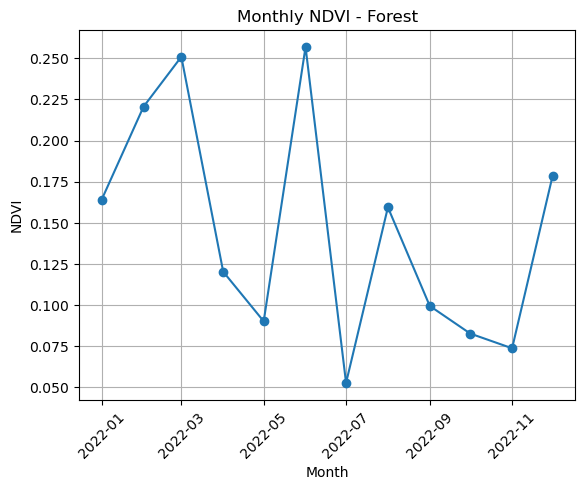

In [25]:
# Plot the NDVI time series for the forest class

import matplotlib.pyplot as plt

plt.figure()
plt.plot(forest_df.index, forest_df["NDVI"], marker='o')
plt.title("Monthly NDVI - Forest")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [26]:
# Function to convert nested JSON structure to a DataFrame with NDVI values and datetime index

import json
import pandas as pd

with open("cropland_ndvi.json") as f:
    cropland_data = json.load(f)

cropland_df = pd.DataFrame.from_dict(
    {k: v[0][0] for k, v in cropland_data.items()},
    orient="index",
    columns=["NDVI"]
)
cropland_df.index = pd.to_datetime(cropland_df.index)

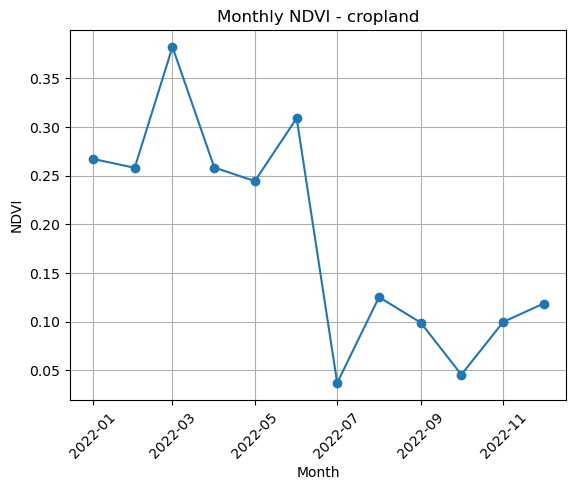

In [27]:
# Plot the NDVI time series for the cropland class

import matplotlib.pyplot as plt

plt.figure()
plt.plot(cropland_df.index, cropland_df["NDVI"], marker='o')
plt.title("Monthly NDVI - cropland")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [28]:
# Function to convert nested JSON structure to a DataFrame with NDVI values and datetime index

import json
import pandas as pd

with open("urban_ndvi.json") as f:
    urban_data = json.load(f)

urban_df = pd.DataFrame.from_dict(
    {k: v[0][0] for k, v in urban_data.items()},
    orient="index",
    columns=["NDVI"]
)
urban_df.index = pd.to_datetime(urban_df.index)

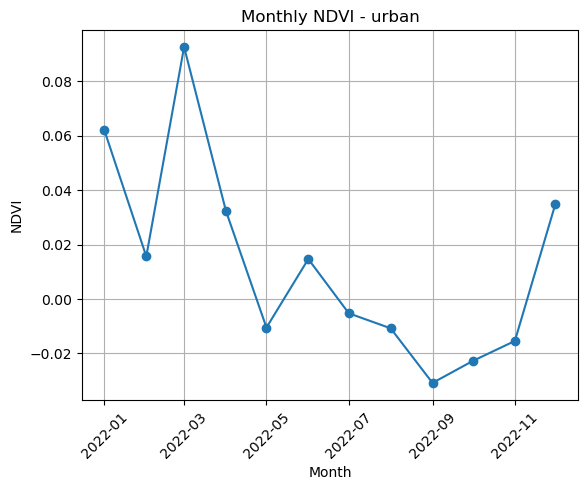

In [29]:
# Plot the NDVI time series for the urban class

import matplotlib.pyplot as plt

plt.figure()
plt.plot(urban_df.index, urban_df["NDVI"], marker='o')
plt.title("Monthly NDVI - urban")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [30]:
# Load JSON results

import matplotlib.pyplot as plt
import json
import pandas as pd

with open("forest_ndvi.json") as f:
    forest_data = json.load(f)
with open("cropland_ndvi.json") as f:
    cropland_data = json.load(f)
with open("urban_ndvi.json") as f:
    urban_data = json.load(f)


In [31]:
# Function to convert nested JSON structure to a DataFrame with NDVI values and datetime index

def json_to_df(ndvi_json):
    df = pd.DataFrame.from_dict(
        {k: v[0][0] for k, v in ndvi_json.items()},
        orient="index",
        columns=["NDVI"]
    )
    df.index = pd.to_datetime(df.index)
    return df

forest_df = json_to_df(forest_data)
cropland_df = json_to_df(cropland_data)
urban_df = json_to_df(urban_data)

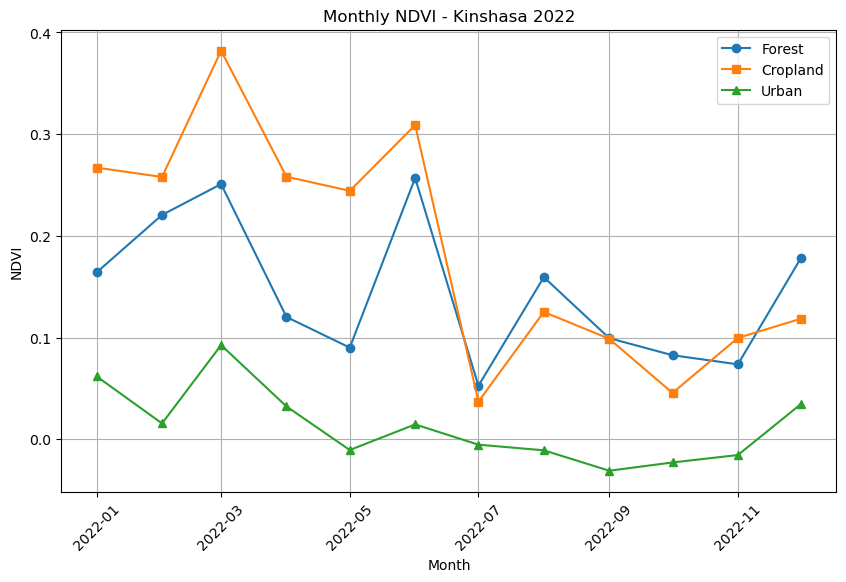

In [32]:
# Plot the NDVI time series for all classes

plt.figure(figsize=(10,6))
plt.plot(forest_df.index, forest_df["NDVI"], marker='o', label="Forest")
plt.plot(cropland_df.index, cropland_df["NDVI"], marker='s', label="Cropland")
plt.plot(urban_df.index, urban_df["NDVI"], marker='^', label="Urban")

plt.title("Monthly NDVI - Kinshasa 2022")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

## 5. Discussion

The NDVI time series for the three land cover classes (forest, cropland, and urban) in Kinshasa for the year 2022 show clear differences in vegetation dynamics.

Overall, cropland areas exhibit the highest NDVI values, reaching a maximum of approximately 0.38 in March. Forest areas show moderate NDVI values, with peaks around 0.25, while urban areas consistently display very low NDVI values, close to zero or even slightly negative. This pattern is consistent with expectations, as urban surfaces contain little vegetation, whereas cropland and forest areas are characterized by higher vegetation cover.

The temporal evolution of NDVI reflects the seasonal climate of Kinshasa, which is characterized by alternating rainy and dry seasons. Higher NDVI values observed between January and March correspond to periods of active vegetation growth, likely linked to favorable moisture conditions.

A noticeable decline in NDVI is observed between April and May for all land cover types. This decrease may be explained by increased cloud cover during the rainy season, which can affect satellite observations despite cloud masking. Additionally, agricultural practices such as harvesting or land preparation could contribute to reduced vegetation signals in cropland areas.

A sharp drop is observed in July across all classes. This is likely associated with the dry season in Kinshasa, during which vegetation activity decreases significantly due to reduced rainfall.

Following this decline, NDVI values increase again from August to September, particularly for forest and cropland areas. This recovery may indicate vegetation regrowth or improved observation conditions due to reduced cloud cover.

Some limitations should be considered in this analysis. Cloud contamination may still influence NDVI values despite the application of cloud masking techniques. Furthermore, NDVI tends to saturate in dense vegetation, which may limit its sensitivity in forest areas. The spatial resolution of Sentinel-2 data may also not capture small-scale heterogeneity within the selected polygons.

## 6. Conclusion

This study analyzed NDVI time series for three land cover classes in Kinshasa using Sentinel-2 data. The results show clear differences between forest, cropland, and urban areas, with cropland exhibiting the highest NDVI values, forest showing moderate values, and urban areas remaining consistently low.

The temporal patterns observed in the NDVI time series reflect the seasonal variability of the region, influenced by alternating rainy and dry seasons. Periods of high NDVI correspond to active vegetation growth, while decreases are associated with climatic conditions and possible data limitations such as cloud cover.

Overall, the results demonstrate that NDVI time series are effective for distinguishing land cover types and analyzing vegetation dynamics over time. Despite some limitations, this approach provides valuable insights into environmental monitoring in tropical regions.